# Q1a - Backprop vs. Hebbian vs. Predictive Coding vs. Node Perturbation

## 1. Setup

In [1]:
import os, io, json, math, contextlib, warnings
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
from matplotlib.lines import Line2D
from matplotlib import animation
from IPython.display import HTML, Image, display

warnings.filterwarnings("ignore", category=UserWarning)

SEED         = 0
NUM_CLASSES  = 3      # MNIST digits 0..NUM_CLASSES-1
NUM_EPOCHS   = 10
NUM_HIDDEN   = 100
BATCH_SIZE   = 32
ACTIVATION   = "sigmoid"

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

set_seed(SEED)
device = torch.device("cpu")
print("torch", torch.__version__, "| device:", device)

torch 2.11.0+cpu | device: cpu


## 2. Data

MNIST restricted to the first `NUM_CLASSES` digits. The Hebbian rule only has a
chance on a small number of classes, so restricting keeps the comparison meaningful
(this mirrors the original tutorial, which used 3 classes for the Hebbian model).

In [2]:
def _find_mnist_root():
    """Use an already-downloaded MNIST if one is nearby, else download to ./data."""
    candidates = [
        "./data",
        os.path.expanduser("~/code/misc/nma/deep-learning/MNIST"),
        "../data", "../../data",
    ]
    for root in candidates:
        if os.path.isdir(os.path.join(root, "MNIST", "raw")):
            return root, False
    return "./data", True


def load_mnist(num_classes=NUM_CLASSES):
    root, need_download = _find_mnist_root()
    transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,)),
    ])
    with contextlib.redirect_stdout(io.StringIO()):
        train_full = torchvision.datasets.MNIST(root, train=True,
                                                download=need_download, transform=transform)
        test_full  = torchvision.datasets.MNIST(root, train=False,
                                                download=need_download, transform=transform)

    def restrict(ds):
        idx = np.where(np.isin(ds.targets.numpy(), np.arange(num_classes)))[0]
        return torch.utils.data.Subset(ds, idx)

    train_set, test_set = restrict(train_full), restrict(test_full)
    print(f"MNIST root: {root}")
    print(f"classes 0..{num_classes-1}:  {len(train_set)} train,  {len(test_set)} test")
    return train_set, test_set


train_set, test_set = load_mnist()
NUM_INPUTS = 784

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]

MNIST root: ./data
classes 0..2:  18623 train,  3147 test


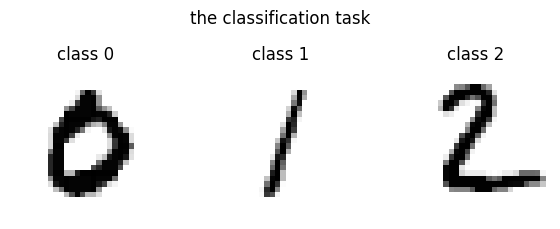

In [3]:
# a quick look at what we are classifying
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(2.0 * NUM_CLASSES, 2.2))
targets = np.array([test_set.dataset.targets[i].item() for i in test_set.indices])
for c in range(NUM_CLASSES):
    i = test_set.indices[np.where(targets == c)[0][0]]
    axes[c].imshow(test_set.dataset.data[i], cmap="gray_r")
    axes[c].set_title(f"class {c}"); axes[c].axis("off")
plt.suptitle("the classification task", y=1.02)
plt.tight_layout(); plt.show()

## 3. Rule 1 - Backprop

The reference. A standard MLP; the loss gradient is computed by autograd and applied
by a plain SGD step. `BasicOptimizer` is kept from the original tutorial so that all
three rules share the same update machinery.

In [4]:
class MultiLayerPerceptron(torch.nn.Module):
    """Simple MLP with one hidden layer (as in the original tutorial)."""

    def __init__(self, num_inputs=NUM_INPUTS, num_hidden=NUM_HIDDEN,
                 num_outputs=NUM_CLASSES, activation_type=ACTIVATION, bias=False):
        super().__init__()
        self.num_inputs, self.num_hidden, self.num_outputs = num_inputs, num_hidden, num_outputs
        self.bias = bias
        self.lin1 = torch.nn.Linear(num_inputs, num_hidden, bias=bias)
        self.lin2 = torch.nn.Linear(num_hidden, num_outputs, bias=bias)
        self.activation = {"sigmoid": torch.nn.Sigmoid(), "tanh": torch.nn.Tanh(),
                           "relu": torch.nn.ReLU()}[activation_type]
        self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, X, y=None):
        # y is unused here, but kept in the signature so every model is interchangeable
        h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
        return self.softmax(self.lin2(h))


class BasicOptimizer(torch.optim.Optimizer):
    """Plain SGD step."""

    def __init__(self, params, lr=0.01, weight_decay=0):
        super().__init__(params, dict(lr=lr, weight_decay=weight_decay))

    def step(self):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                if group["weight_decay"]:
                    p.grad = p.grad.add(p, alpha=group["weight_decay"])
                p.data.add_(p.grad, alpha=-group["lr"])

## 4. Rule 2 - Hebbian learning with output clamping

"Fire together, wire together": the weight change is the product of the presynaptic
input and the postsynaptic output, with **no error signal and no backward pass**.

The one concession to supervision is *output clamping*: at the last layer the actual
output is replaced by the one-hot target when forming the update, so the top layer
learns to associate hidden patterns with the correct class. The hidden layer remains
entirely unsupervised.

$$\Delta W \;\propto\; \text{post}^{\top}\,\text{pre}$$

In [5]:
class HebbianFunction(torch.autograd.Function):
    """Hijacks autograd's backward() to deliver a Hebbian update instead of a gradient."""

    @staticmethod
    def forward(context, input, weight, bias=None, nonlinearity=None, target=None):
        output = input.mm(weight.t())
        if bias is not None:
            output = output + bias.unsqueeze(0).expand_as(output)
        if nonlinearity is not None:
            output = nonlinearity(output)
        # clamping: if a target is supplied, learn towards it rather than towards the output
        output_for_update = output if target is None else target
        context.save_for_backward(input, weight, bias, output_for_update)
        return output

    @staticmethod
    def backward(context, grad_output=None):
        input, weight, bias, output_for_update = context.saved_tensors
        grad_weight = grad_bias = None

        if context.needs_input_grad[1]:
            grad_weight = output_for_update.t().mm(input)     # post^T . pre
            grad_weight = grad_weight / len(input)            # average over the batch
            grad_weight = grad_weight - grad_weight.mean(axis=0)   # centre ACROSS OUTPUT UNITS
            grad_weight = -grad_weight                        # negate: the optimizer subtracts

        if bias is not None and context.needs_input_grad[2]:
            grad_bias = output_for_update.mean(axis=0)
            grad_bias = -(grad_bias - grad_bias.mean())

        return None, grad_weight, grad_bias, None, None


class HebbianMultiLayerPerceptron(MultiLayerPerceptron):
    """MLP whose layers learn by the Hebbian rule above."""

    def __init__(self, clamp_output=True, **kwargs):
        self.clamp_output = clamp_output
        super().__init__(**kwargs)

    def forward(self, X, y=None):
        h = HebbianFunction.apply(X.reshape(-1, self.num_inputs),
                                  self.lin1.weight, self.lin1.bias, self.activation)
        targets = None
        if y is not None and self.clamp_output:
            targets = F.one_hot(y, num_classes=self.num_outputs).float()
        return HebbianFunction.apply(h, self.lin2.weight, self.lin2.bias,
                                     self.softmax, targets)

## 5. Rule 3 - Node Perturbation

Node perturbation estimates gradients by random search rather than backprop: perturb neuron activity, see whether the loss got better or worse, and reinforce whatever perturbation helped. It's in the same family as SPSA and REINFORCE, and formally equivalent to a reward-modulated, three-factor Hebbian plasticity rule. Unlike the Hebbian rule above, it needs a single *global* signal (whether the whole network's loss improved), not just local pre/post-synaptic activity -- so it can't be written as a per-layer custom autograd `Function`. The implementation below runs a clean and a perturbed forward pass and computes the weight update by hand instead.

>
$$
\begin{aligned}
\text{Clean pass:}\quad & h = f(W_1 x), \qquad y = \text{softmax}(W_2 h) \\[4pt]
\text{Perturbed pass:}\quad & h' = h + \xi_h, \qquad y' = \text{softmax}(W_2 h' + \xi_{\text{out}}), \qquad \xi_h, \xi_{\text{out}} \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2) \\[4pt]
\text{Loss delta:}\quad & \delta = L(y, t) - L(y', t) \\[4pt]
\text{Update:}\quad & \Delta W_1 = \frac{\delta}{\sigma^2}\, \xi_h\, x^\top, \qquad \Delta W_2 = \frac{\delta}{\sigma^2}\, \xi_{\text{out}}\, (h')^\top, \qquad W \leftarrow W + \eta \, \Delta W
\end{aligned}
$$
>

Hyperparameters below (`noise_std=0.15, lr=0.01`) were tuned across four stages in a companion notebook, not re-derived here. Full tuning process, all four stages, and the standalone model: [MLP_with_node_perturbation.ipynb](https://github.com/varungr890/TardyGrad/blob/main/Q1_Model_Comparison/Node_Perturbation/MLP_with_node_perturbation.ipynb).

**A note on reliability:** the single-seed run above is consistent with a broader check already done on this same 3-class task — across 5 seeds at noise_std=0.15, lr=0.01, node perturbation reached 98.0% ± 0.2% accuracy (see the companion notebook linked above). This is offered as context for this rule specifically, not a claim about how backprop, Hebbian, or predictive coding would look across seeds — that's outside what this section can speak to.

In [6]:
class NodePerturbationMultiLayerPerceptron(MultiLayerPerceptron):
    """MLP trained by node perturbation instead of backprop.

    perturbed_forward() runs a clean pass and a perturbed pass under
    torch.no_grad(); node_perturbation_step() (below) uses the difference
    in loss between the two to compute a weight update by hand and sets
    .grad directly -- BasicOptimizer only ever reads .grad, so it applies
    this update with no changes needed on its end.

    Output-layer noise is injected into the pre-softmax logits rather than
    the post-softmax probabilities, so the perturbed output always stays a
    valid probability distribution.
    """

    def __init__(self, noise_std=0.15, **kwargs):
        self.noise_std = noise_std
        self._np_cache = None
        super().__init__(**kwargs)
        if self.bias:
            raise NotImplementedError(
                "NodePerturbationMultiLayerPerceptron does not yet compute bias "
                "updates (bias=False everywhere else in this notebook)."
                )

    def perturbed_forward(self, X, generator=None):
        X = X.reshape(-1, self.num_inputs)
        with torch.no_grad():
            h_clean = self.activation(self.lin1(X))
            out_clean = self.softmax(self.lin2(h_clean))

            xi_h = self.noise_std * torch.randn(h_clean.shape, generator=generator)
            h_pert = h_clean + xi_h

            out_logits_pert = self.lin2(h_pert)
            xi_out = self.noise_std * torch.randn(out_logits_pert.shape, generator=generator)
            out_pert = self.softmax(out_logits_pert + xi_out)

            self._np_cache = {"X": X, "h_pert": h_pert, "xi_h": xi_h, "xi_out": xi_out}
        return out_clean, out_pert


def node_perturbation_step(net, X, y, criterion_none, optimizer, generator=None):
    """One training step of node perturbation -- see class docstring above."""
    out_clean, out_pert = net.perturbed_forward(X, generator=generator)

    with torch.no_grad():
        eps = 1e-12  # numerical floor so log(0) never happens on a confident wrong prediction
        loss_clean = criterion_none(torch.log(out_clean.clamp_min(eps)), y)
        loss_pert = criterion_none(torch.log(out_pert.clamp_min(eps)), y)
        delta_loss = loss_clean - loss_pert  # positive = perturbation reduced the loss = reinforce it

        cache = net._np_cache
        batch_size = X.shape[0]

        scaled_xi_h = delta_loss.unsqueeze(1) * cache["xi_h"] / net.noise_std**2
        grad_W1_update = scaled_xi_h.t().mm(cache["X"]) / batch_size

        scaled_xi_out = delta_loss.unsqueeze(1) * cache["xi_out"] / net.noise_std**2
        grad_W2_update = scaled_xi_out.t().mm(cache["h_pert"]) / batch_size

        # BasicOptimizer SUBTRACTS grad * lr -- negate so it effectively ADDS the update
        net.lin1.weight.grad = -grad_W1_update
        net.lin2.weight.grad = -grad_W2_update

    optimizer.step()

## 6. Rule 4 - Predictive coding

### 6.1 How the network is wired

This is the part worth being precise about, because a predictive coding network (PCN)
is *not* just an MLP with a different update rule - it has **twice as many neurons**.

**Two populations per layer.** Layer $l$ carries $n_l$ **value nodes** $x_l$ and
$n_l$ **error nodes** $\varepsilon_l$, paired one-to-one.

* **Value nodes $x_l$** hold the network's current belief about what layer $l$ should be.
  Unlike an MLP activation, they are *state variables* that move during inference.
* **Error nodes $\varepsilon_l$** hold the mismatch between that belief and what the
  layer below predicted for it.

**Three kinds of connection.**

1. **Prediction (top-down), learned.** Layer $l-1$ predicts layer $l$ through the weights $W_l$:
   $$\mu_l = W_l\, f(x_{l-1})$$
2. **The one-to-one error connection, weight fixed at 1.** Each error node is driven
   *excitatorily* by its own value node and *inhibitorily* by the prediction:
   $$\varepsilon_l = x_l - \mu_l$$
   This subtraction is the whole trick - an error node is a neuron that computes a difference.
3. **Error feedback (bottom-up), the same synapse read backwards.** Error nodes send
   their signal back up through $W_l^{\top}$. This is the *transpose of the forward
   weight*, not a separately learned matrix - it falls out of the derivative of the
   objective. (It is also the least biologically comfortable part of the model: real
   cortex shows no such exact symmetry.)

**What is clamped.** The image is pinned onto $x_0$. During *training* the one-hot
label is also pinned onto $x_L$. During *testing* only the input is pinned, and a
plain forward sweep reads out the answer.

**One objective for everything.** Both phases do gradient descent on the same quantity,
the free energy - just with respect to different variables:
$$F = \tfrac{1}{2}\sum_l \lVert \varepsilon_l \rVert^2$$

### 6.2 The two timescales

| | fast (inference) | slow (learning) |
|---|---|---|
| what moves | value nodes $x_l$ | weights $W_l$ |
| what is frozen | weights | value and error nodes |
| update | $\dot{x}_l = -\varepsilon_l + f'(x_l)\,W_{l+1}^{\top}\varepsilon_{l+1}$ | $\Delta W_l = \alpha\,\varepsilon_l\,f(x_{l-1})^{\top}$ |
| runs | $T$ steps per example | once per example |

Each value node is pulled by exactly two forces: *"I disagree with what was predicted
for me"* ($-\varepsilon_l$) and *"the layer above me is unhappy and I am partly
responsible"* ($+f'(x_l) W_{l+1}^{\top}\varepsilon_{l+1}$). Relaxation ends where they balance.

The weight update is **local**: $\Delta W_l$ needs only the error node on one side of
the synapse and the firing rate on the other. Both are physically present at the synapse.
That is exactly what backprop's $\delta$ lacks - backprop must *compute* its deltas by a
non-local recursion, whereas here the error is a real node value the dynamics already settled on.

### 6.3 Where the loss enters

There is no backward *pass*. Clamping the label onto $x_L$ makes $x_L$ disagree with
$\mu_L$, and since $x_L$ cannot move, that disagreement is held permanently in
$\varepsilon_L$. **At the instant of clamping, every other error node in the network
is exactly zero.** During relaxation the error physically spreads: $\varepsilon_L$ pushes
$x_{L-1}$, which displaces $x_{L-1}$ away from what *its* parent predicted, which creates
$\varepsilon_{L-1}$, and so on. Error propagation is an emergent transient of the relaxation.

We verify both claims numerically in section 8.

In [7]:
class PredictiveCodingNetwork:
    """Discriminative predictive coding network, implemented from scratch.

    Value nodes  x[0..L]        x[0] = image (clamped), x[L] = label (clamped when training)
    Error nodes  eps[1..L]      eps[l] = x[l] - mu[l]
    Prediction   mu[l] = W[l] @ f(x[l-1])

    Free energy  F        = 0.5 * sum_l ||eps[l]||^2
    Inference    x[l]    <- x[l] - gamma * (eps[l] - f'(x[l]) * (eps[l+1] @ W[l+1]))
    Learning     W[l]    <- W[l] + alpha * eps[l].T @ f(x[l-1]) / B

    No autograd: every quantity is explicit so it can be inspected and animated.
    """

    def __init__(self, sizes=(NUM_INPUTS, NUM_HIDDEN, NUM_CLASSES),
                 activation=ACTIVATION, T=20, gamma=0.1, seed=None):
        self.sizes, self.L = list(sizes), len(sizes) - 1
        self.T, self.gamma = T, gamma
        self.num_inputs, self.num_outputs = sizes[0], sizes[-1]
        if seed is not None:
            torch.manual_seed(seed)

        acts = {"sigmoid": (torch.sigmoid, lambda z: torch.sigmoid(z) * (1 - torch.sigmoid(z))),
                "tanh":    (torch.tanh,    lambda z: 1 - torch.tanh(z) ** 2),
                "identity":(lambda z: z,   torch.ones_like)}
        # identity on the input layer so the forward sweep matches the backprop MLP exactly
        self.acts = [acts["identity"]] + [acts[activation]] * (self.L - 1)

        self.W = [None]                       # index 0 unused, so W[l] reads naturally
        for l in range(1, self.L + 1):
            bound = 1.0 / np.sqrt(sizes[l - 1])
            self.W.append(torch.empty(sizes[l], sizes[l - 1]).uniform_(-bound, bound))

    # ---- helpers -------------------------------------------------------
    def f(self, l, x):  return self.acts[l][0](x)
    def df(self, l, x): return self.acts[l][1](x)

    def predict_mu(self, l, x_below):
        """Top-down prediction of layer l made by layer l-1."""
        return self.f(l - 1, x_below) @ self.W[l].T

    def feedforward(self, X):
        """Initialise the value nodes with a pure forward sweep (x[l] = mu[l])."""
        x = [X.reshape(-1, self.num_inputs)]
        for l in range(1, self.L + 1):
            x.append(self.predict_mu(l, x[l - 1]))
        return x

    def errors(self, x):
        return [None] + [x[l] - self.predict_mu(l, x[l - 1]) for l in range(1, self.L + 1)]

    def free_energy(self, eps):
        return sum(0.5 * (e ** 2).sum(dim=1) for e in eps[1:])

    # ---- fast timescale ------------------------------------------------
    def infer(self, X, target=None, T=None, record=False):
        """Relax the value nodes with the weights held FIXED.

        If a target is supplied it is clamped onto x[L]; that clamp is the only
        thing that injects error into the network.
        """
        T = self.T if T is None else T
        x = self.feedforward(X)
        if target is not None:
            x[self.L] = target.clone()

        trace = []
        if record:
            trace.append(self._snapshot(x, self.errors(x), 0))

        for t in range(1, T + 1):
            eps = self.errors(x)
            new_x = [xi.clone() for xi in x]
            top = self.L if target is not None else self.L + 1   # clamped layers do not move
            for l in range(1, top):
                td = eps[l + 1] @ self.W[l + 1] if l < self.L else 0.0
                new_x[l] = x[l] - self.gamma * (eps[l] - self.df(l, x[l]) * td)
            x = new_x
            if record:
                trace.append(self._snapshot(x, self.errors(x), t))

        eps = self.errors(x)
        return (x, eps, trace) if record else (x, eps)

    # ---- slow timescale ------------------------------------------------
    def learn(self, x, eps, lr):
        """Local Hebbian weight update with the value nodes held FIXED."""
        B = x[0].shape[0]
        for l in range(1, self.L + 1):
            self.W[l] = self.W[l] + lr * (eps[l].T @ self.f(l - 1, x[l - 1]) / B)

    def train_on_batch(self, X, target, lr):
        x, eps = self.infer(X, target=target)
        self.learn(x, eps, lr)
        return self.free_energy(eps).mean().item()

    # ---- readout -------------------------------------------------------
    def logits(self, X):
        """Test time: clamp the input only, sweep forward, read the top layer."""
        with torch.no_grad():
            return self.feedforward(X)[self.L]

    def _snapshot(self, x, eps, step):
        return {"step": step,
                "x":   [xi[0].detach().clone().numpy() for xi in x],
                "eps": [None] + [e[0].detach().clone().numpy() for e in eps[1:]],
                "F":   float(self.free_energy(eps)[0])}

## 7. One interface, four rules

Each rule is wrapped in a `Learner` exposing exactly two methods:

* `probs(X)` - class probabilities, for evaluation
* `train_batch(X, y)` - perform one update

`train_extended` never asks which rule it is driving, so the rules are genuinely
swappable. **Every model is scored with the same yardstick** - cross-entropy and
accuracy computed identically - even though each optimises its own objective internally.

In [8]:
class Learner:
    """Common interface. Subclasses implement probs() and train_batch()."""
    name, num_outputs = "learner", None
    def probs(self, X):            raise NotImplementedError
    def train_batch(self, X, y):   raise NotImplementedError


class BackpropLearner(Learner):
    name = "backprop"
    def __init__(self, num_outputs, num_hidden=NUM_HIDDEN, lr=0.01, **kw):
        self.net = MultiLayerPerceptron(num_hidden=num_hidden, num_outputs=num_outputs)
        self.opt = BasicOptimizer(self.net.parameters(), lr=lr)
        self.criterion, self.num_outputs = torch.nn.NLLLoss(), num_outputs

    def probs(self, X):
        with torch.no_grad():
            return self.net(X)

    def train_batch(self, X, y):
        loss = self.criterion(torch.log(self.net(X, y=y) + 1e-12), y)
        self.opt.zero_grad(); loss.backward(); self.opt.step()


class HebbianLearner(Learner):
    name = "hebbian"
    def __init__(self, num_outputs, num_hidden=NUM_HIDDEN, lr=(2.5e-5, 8e-4),
                 centre_rows=False, **kw):
        self.net = HebbianMultiLayerPerceptron(num_hidden=num_hidden,
                                               num_outputs=num_outputs, clamp_output=True)
        self.opt = BasicOptimizer([{"params": self.net.lin1.parameters(), "lr": lr[0]},
                                   {"params": self.net.lin2.parameters(), "lr": lr[1]}])
        self.criterion, self.num_outputs = torch.nn.NLLLoss(), num_outputs
        self.centre_rows = centre_rows      # the fix explored in section 10

    def probs(self, X):
        with torch.no_grad():
            return self.net(X)

    def train_batch(self, X, y):
        loss = self.criterion(torch.log(self.net(X, y=y) + 1e-12), y)
        self.opt.zero_grad(); loss.backward(); self.opt.step()
        if self.centre_rows:
            with torch.no_grad():
                for lin in (self.net.lin1, self.net.lin2):
                    lin.weight.data -= lin.weight.data.mean(dim=1, keepdim=True)


class PredictiveCodingLearner(Learner):
    name = "predictive coding"
    def __init__(self, num_outputs, num_hidden=NUM_HIDDEN, lr=0.05, T=20, gamma=0.1, **kw):
        self.net = PredictiveCodingNetwork(sizes=(NUM_INPUTS, num_hidden, num_outputs),
                                           T=T, gamma=gamma)
        self.lr, self.num_outputs = lr, num_outputs

    def probs(self, X):
        return torch.softmax(self.net.logits(X), dim=1)

    def train_batch(self, X, y):
        self.net.train_on_batch(X, F.one_hot(y, self.num_outputs).float(), lr=self.lr)


class NodePerturbationLearner(Learner):
    name = "node perturbation"
    def __init__(self, num_outputs, num_hidden=NUM_HIDDEN, lr=0.01, noise_std=0.15, **kw):
        self.net = NodePerturbationMultiLayerPerceptron(
            num_hidden=num_hidden, num_outputs=num_outputs, noise_std=noise_std
            )
        self.opt = BasicOptimizer(self.net.parameters(), lr=lr)
        self.criterion_none, self.num_outputs = torch.nn.NLLLoss(reduction="none"), num_outputs

    def probs(self, X):
        with torch.no_grad():
            return self.net(X)

    def train_batch(self, X, y):
        node_perturbation_step(self.net, X, y, self.criterion_none, self.opt)


LEARNERS = {"backprop": BackpropLearner,
            "hebbian": HebbianLearner,
            "predictive_coding": PredictiveCodingLearner,
            "node_perturbation": NodePerturbationLearner}

In [9]:
def evaluate(learner, loader):
    """The same yardstick for every rule: cross-entropy and accuracy."""
    total_loss = total_correct = n = 0
    for X, y in loader:
        p = learner.probs(X)
        total_loss    += -torch.log(p[torch.arange(len(y)), y] + 1e-12).sum().item()
        total_correct += (p.argmax(1) == y).sum().item()
        n += len(y)
    return total_loss / n, 100.0 * total_correct / n


def train_extended(model_type, train_set=None, test_set=None, num_classes=NUM_CLASSES,
                   num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, seed=SEED,
                   verbose=True, **learner_kwargs):
    """Train any of the three rules. This function is rule-agnostic."""
    train_set = globals()["train_set"] if train_set is None else train_set
    test_set  = globals()["test_set"]  if test_set  is None else test_set

    set_seed(seed)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=256)

    learner = LEARNERS[model_type](num_outputs=num_classes, **learner_kwargs)

    results = {"loss": [], "acc": [], "name": learner.name}
    loss, acc = evaluate(learner, test_loader)      # epoch 0 = before any training
    results["loss"].append(loss); results["acc"].append(acc)

    for epoch in range(num_epochs):
        for X, y in train_loader:
            learner.train_batch(X, y)
        loss, acc = evaluate(learner, test_loader)
        results["loss"].append(loss); results["acc"].append(acc)
        if verbose:
            print(f"  {learner.name:18s} epoch {epoch+1:2d}/{num_epochs}  "
                  f"loss={loss:.4f}  acc={acc:5.2f}%")
    return learner, results

## 8. Train all four

In [10]:
%%time
results = {}
learners = {}
for model_type in ["backprop", "predictive_coding", "hebbian", "node_perturbation"]:
    print(f"--- {model_type} ---")
    learners[model_type], results[model_type] = train_extended(model_type)
    print()

--- backprop ---
  backprop           epoch  1/10  loss=0.1321  acc=97.20%
  backprop           epoch  2/10  loss=0.0824  acc=98.16%
  backprop           epoch  3/10  loss=0.0664  acc=98.32%
  backprop           epoch  4/10  loss=0.0575  acc=98.47%
  backprop           epoch  5/10  loss=0.0521  acc=98.51%
  backprop           epoch  6/10  loss=0.0483  acc=98.70%
  backprop           epoch  7/10  loss=0.0457  acc=98.60%
  backprop           epoch  8/10  loss=0.0438  acc=98.63%
  backprop           epoch  9/10  loss=0.0415  acc=98.89%
  backprop           epoch 10/10  loss=0.0406  acc=98.86%

--- predictive_coding ---
  predictive coding  epoch  1/10  loss=0.6061  acc=97.87%
  predictive coding  epoch  2/10  loss=0.5917  acc=98.57%
  predictive coding  epoch  3/10  loss=0.5816  acc=98.89%
  predictive coding  epoch  4/10  loss=0.5751  acc=99.14%
  predictive coding  epoch  5/10  loss=0.5725  acc=99.05%
  predictive coding  epoch  6/10  loss=0.5701  acc=99.14%
  predictive coding  epoch  

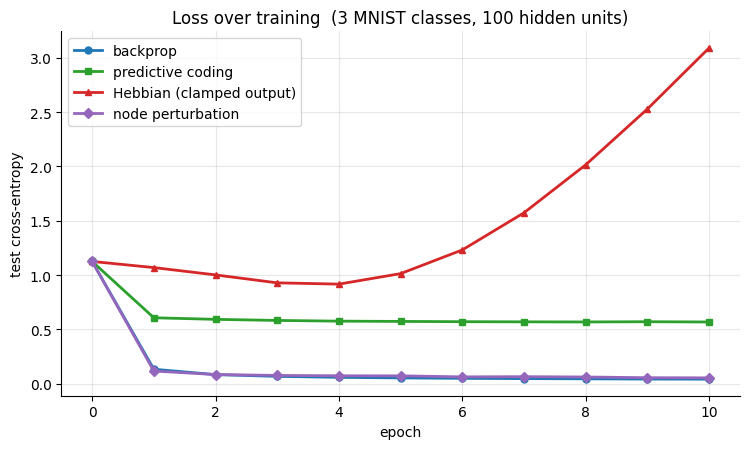

final loss: {'backprop': 0.0406, 'predictive_coding': 0.5674, 'hebbian': 3.0925, 'node_perturbation': 0.0525}


In [11]:
STYLE = {
    "backprop":          dict(color="#1F77B4", marker="o", label="backprop"),
    "predictive_coding": dict(color="#2CA02C", marker="s", label="predictive coding"),
    "hebbian":           dict(color="#D62728", marker="^", label="Hebbian (clamped output)"),
    "node_perturbation": dict(color="#9467BD", marker="D", label="node perturbation"),
}

fig, ax = plt.subplots(figsize=(7.6, 4.6))
for k, r in results.items():
    ax.plot(r["loss"], lw=2, ms=5, **STYLE[k])
ax.set_xlabel("epoch"); ax.set_ylabel("test cross-entropy")
ax.set_title(f"Loss over training  ({NUM_CLASSES} MNIST classes, {NUM_HIDDEN} hidden units)")
ax.legend(); ax.grid(alpha=.3)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print("final loss:", {k: round(r['loss'][-1], 4) for k, r in results.items()})

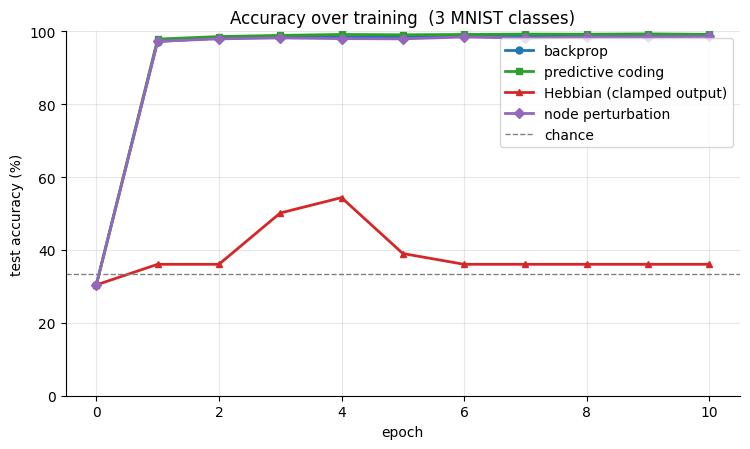

final accuracy: {'backprop': 98.86, 'predictive_coding': 99.17, 'hebbian': 36.07, 'node_perturbation': 98.6}


In [12]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))
for k, r in results.items():
    ax.plot(r["acc"], lw=2, ms=5, **STYLE[k])
ax.axhline(100 / NUM_CLASSES, ls="--", color="grey", lw=1, label="chance")
ax.set_xlabel("epoch"); ax.set_ylabel("test accuracy (%)")
ax.set_title(f"Accuracy over training  ({NUM_CLASSES} MNIST classes)")
ax.legend(); ax.grid(alpha=.3); ax.set_ylim(0, 100)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print("final accuracy:", {k: round(r['acc'][-1], 2) for k, r in results.items()})

### Reading these two graphs together

The loss ordering is the expected one - backprop best, predictive coding second,
Hebbian far behind. But the two graphs disagree about predictive coding, and the
disagreement is informative rather than a bug:

**Predictive coding's cross-entropy is inflated by a scale artefact.** It is trained to
drive a *linear* output towards a one-hot vector under squared error, so its outputs
live on a small scale; a softmax over them is comparatively flat, which costs
cross-entropy even when the ranking is right. Its **accuracy** is the fairer read of
decision quality, and there it is level with backprop. The honest summary is:
*predictive coding matches backprop on this task; its loss curve mostly reflects
output calibration, not worse learning.*

**The Hebbian curve is a genuine failure**, and section 10 diagnoses it.

**Node perturbation sits between predictive coding and Hebbian.** Like Hebbian, its
update is a local, biologically plausible rule; unlike Hebbian, every layer's update is
scaled by the same global loss signal, so it doesn't exhibit Hebbian's collapse. That
signal is estimated by random search rather than computed exactly, so expect a noisier,
slower-converging curve than backprop or predictive coding -- but a real, generalizing
one. In a separate 15-epoch run on this same 3-class task, at these settings, it reached
98.0% +/- 0.2% accuracy across 5 seeds. See section 6 above, and the companion notebook
linked there, for the full four-stage tuning process behind `noise_std=0.15, lr=0.01`.

## 9. Does predictive coding really approximate backprop?

Two checks on the claims made in section 5.

**Check 1 - the weight updates line up with the gradient.** We take an untrained
network, compute the true gradient of $\tfrac12\lVert \mu_L - t\rVert^2$ by autograd,
and compare it to what the PCN's relaxation-then-Hebbian procedure produces.

In [13]:
set_seed(1)
Xb, yb = next(iter(torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)))
tb = F.one_hot(yb, NUM_CLASSES).float()

def cosine(a, b):
    a, b = a.flatten(), b.flatten()
    return float(a @ b / (a.norm() * b.norm()))

print("cosine similarity between the PCN update and the true backprop gradient\n")
print(f"{'T (relaxation steps)':>22s} {'layer 1':>12s} {'layer 2':>12s}")
for T in [1, 2, 5, 20, 100]:
    net = PredictiveCodingNetwork(sizes=(NUM_INPUTS, NUM_HIDDEN, NUM_CLASSES),
                                  T=T, gamma=0.1, seed=1)
    W1 = net.W[1].clone().requires_grad_(True)
    W2 = net.W[2].clone().requires_grad_(True)
    out = torch.sigmoid(Xb.reshape(-1, NUM_INPUTS) @ W1.T) @ W2.T
    g1, g2 = torch.autograd.grad(0.5 * ((out - tb) ** 2).sum(1).mean(), [W1, W2])

    xs, eps = net.infer(Xb, target=tb)
    B = len(Xb)
    d1 = eps[1].T @ net.f(0, xs[0]) / B
    d2 = eps[2].T @ net.f(1, xs[1]) / B
    print(f"{T:>22d} {cosine(d1, -g1):>12.6f} {cosine(d2, -g2):>12.6f}")

cosine similarity between the PCN update and the true backprop gradient

  T (relaxation steps)      layer 1      layer 2
                     1     1.000003     1.000000
                     2     0.999998     0.999999
                     5     1.000003     0.999995
                    20     0.999999     0.999979
                   100     0.999994     0.999973


Essentially 1.0 - the PCN is climbing the same hill backprop is, without ever computing
a gradient. The agreement is closest for few relaxation steps and drifts very slightly as
the network settles further from its feedforward state, which is exactly the behaviour the
theory predicts: the approximation is exact when the output error is small and degrades
as the clamp displaces the network further.

**Check 2 - error is born at the output and spreads one layer per step.** We use a deeper
network (784-100-50-K) so the wave has somewhere to travel.

In [14]:
set_seed(2)
deep = PredictiveCodingNetwork(sizes=(NUM_INPUTS, 100, 50, NUM_CLASSES), T=10, gamma=0.2, seed=2)
_, _, trace = deep.infer(Xb[:1], target=tb[:1], T=8, record=True)

print(f"{'step':>5s} {'||eps_1||':>12s} {'||eps_2||':>12s} {'||eps_3|| (output)':>20s} {'F':>10s}")
for s in trace:
    n = [np.linalg.norm(s["eps"][l]) for l in (1, 2, 3)]
    print(f"{s['step']:>5d} {n[0]:>12.6f} {n[1]:>12.6f} {n[2]:>20.6f} {s['F']:>10.5f}")

print("\nAt t=0 only the clamped output carries error.")
print("Layer 2 becomes non-zero after 1 step, layer 1 after 2 - the error travels.")

 step    ||eps_1||    ||eps_2||   ||eps_3|| (output)          F
    0     0.000000     0.000000             0.704551    0.24820
    1     0.000000     0.021710             0.701206    0.24608
    2     0.000602     0.038892             0.698546    0.24474
    3     0.001559     0.052507             0.696427    0.24389
    4     0.002700     0.063309             0.694739    0.24334
    5     0.003912     0.071888             0.693391    0.24299
    6     0.005119     0.078711             0.692314    0.24276
    7     0.006273     0.084144             0.691452    0.24261
    8     0.007346     0.088475             0.690762    0.24252

At t=0 only the clamped output carries error.
Layer 2 becomes non-zero after 1 step, layer 1 after 2 - the error travels.


## 10. What actually happens in a predictive coding pass

The drawing code below renders one moment in the life of the network. A small
network (784-6-5-3) is used so individual neurons are visible.

**How to read the diagram**

* **Circles** are value nodes $x_l$; **squares** are error nodes $\varepsilon_l$.
* Circle colour = the node's value; square colour and border thickness = the size of its error.
  A white square with a thin border means *zero error*.
* **Grey arrows** carry predictions downstream; **dashed orange arrows** carry error back upstream.
* **Green outlines** mark clamped nodes, which cannot move.

In [15]:
VAL_CMAP, ERR_CMAP = plt.get_cmap("RdBu_r"), plt.get_cmap("PuOr_r")
C_VAL, C_ERR, C_PRED, C_CLAMP = "#2C6FBB", "#D1651A", "#8C8C8C", "#1B7F4B"

def _norm(v, s):
    return np.clip(0.5 + 0.5 * v / max(s, 1e-12), 0, 1)


class PCScene:
    """Draws the predictive coding network at one moment in time."""

    def __init__(self, net, aspect=1.0, node_cap=6, layer_names=None):
        self.net, self.L, self.sizes = net, net.L, net.sizes
        self.node_cap, self.aspect = node_cap, aspect
        self.names = layer_names or (["input"] +
                                     [f"hidden {i}" for i in range(1, self.L)] + ["output"])
        self.xs = np.linspace(0.11, 0.88, self.L + 1)
        nmax = max(min(s, node_cap) for s in self.sizes[1:])
        spacing = 0.42 / max(nmax - 1, 1)
        self.R = min(0.019, 0.42 * spacing / max(aspect, 1e-6))   # keeps nodes circular

    def node_ys(self, l):
        n = min(self.sizes[l], self.node_cap)
        return np.array([0.5]) if n == 1 else np.linspace(0.72, 0.30, n)

    def draw(self, ax, snap, phase, img=None, flash=False, scales=None, subtitle=None):
        ax.clear(); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
        L, sc_x, sc_e = self.L, scales["x"], scales["e"]

        if img is not None:
            ia = ax.inset_axes([self.xs[0] - 0.070, 0.38, 0.14, 0.26])
            ia.imshow(img.reshape(28, 28), cmap="gray_r"); ia.set_xticks([]); ia.set_yticks([])
            for sp in ia.spines.values():
                sp.set_color(C_CLAMP); sp.set_linewidth(2.5)
            ax.text(self.xs[0], 0.655, "INPUT CLAMPED", ha="center", va="bottom",
                    fontsize=8.5, color=C_CLAMP, fontweight="bold")
            ax.text(self.xs[0], 0.345, r"$x_0$", ha="center", va="top", fontsize=10, color=C_VAL)

        for l in range(1, L + 1):                     # connections
            x0, x1 = self.xs[l - 1], self.xs[l]
            ax.annotate("", xy=(x1 - 0.040, 0.50), xytext=(x0 + 0.050, 0.50),
                        arrowprops=dict(arrowstyle="-|>", lw=4.5 if flash else 2.0,
                                        color="#C62828" if flash else C_PRED,
                                        shrinkA=0, shrinkB=0, alpha=.92))
            ax.text((x0 + x1) / 2, 0.522, r"$\mu_%d=W_%d\,f(x_%d)$" % (l, l, l - 1),
                    ha="center", va="bottom", fontsize=8.5, color="#444")
            if l - 1 >= 1:
                ax.annotate("", xy=(x0 + 0.050, 0.445), xytext=(x1 - 0.040, 0.445),
                            arrowprops=dict(arrowstyle="-|>", color=C_ERR, lw=2.0,
                                            shrinkA=0, shrinkB=0, alpha=.92, linestyle=(0, (4, 2))))
                ax.text((x0 + x1) / 2, 0.428, r"$W_%d^{\top}\varepsilon_%d$" % (l, l),
                        ha="center", va="top", fontsize=8.5, color=C_ERR)

        for l in range(1, L + 1):                     # nodes
            xv, ys = self.xs[l], self.node_ys(l)
            xvals, evals = snap["x"][l][:len(ys)], snap["eps"][l][:len(ys)]
            clamped = (l == L)
            for k, yy in enumerate(ys):
                ax.add_patch(Ellipse((xv, yy), 2 * self.R, 2 * self.R * self.aspect,
                                     facecolor=VAL_CMAP(_norm(xvals[k], sc_x)),
                                     edgecolor=C_CLAMP if clamped else "black",
                                     lw=2.4 if clamped else 0.8, zorder=5))
                eh = 1.9 * self.R * self.aspect
                ax.add_patch(Rectangle((xv + 0.028, yy - eh / 2), 0.028, eh,
                                       facecolor=ERR_CMAP(_norm(evals[k], sc_e)),
                                       edgecolor="black",
                                       lw=0.6 + 2.2 * min(abs(evals[k]) / max(sc_e, 1e-12), 1),
                                       zorder=5))
                ax.plot([xv + self.R, xv + 0.028], [yy, yy], color="k", lw=0.7, zorder=4)

            ax.text(xv + 0.014, 0.775, self.names[l], ha="center", va="bottom", fontsize=9.5)
            ax.text(xv, 0.250, r"$x_%d$" % l, ha="center", va="top", fontsize=10, color=C_VAL)
            ax.text(xv + 0.043, 0.250, r"$\varepsilon_%d$" % l, ha="center", va="top",
                    fontsize=10, color=C_ERR)
            en = float(np.linalg.norm(evals))
            ax.text(xv + 0.014, 0.200, r"$\|\varepsilon_%d\|$=%.4f" % (l, en), ha="center",
                    va="top", fontsize=8.5, color=C_ERR if en > 1e-6 else "#BBBBBB",
                    fontweight="bold" if en > 1e-6 else "normal")
            if clamped:
                ax.text(xv + 0.014, 0.815, "TARGET CLAMPED", ha="center", va="bottom",
                        fontsize=8.5, color=C_CLAMP, fontweight="bold")

        if flash:
            ax.text(0.70, 0.135, r"$\Delta W_l=\alpha\,\varepsilon_l\,f(x_{l-1})^{\top}$"
                    "   -   post-synaptic error $\\times$ pre-synaptic rate, purely local",
                    ha="center", fontsize=10, color="#C62828", fontweight="bold")

        ax.text(0.5, 0.975, phase, ha="center", va="center", fontsize=13, fontweight="bold")
        if subtitle:
            ax.text(0.5, 0.905, subtitle, ha="center", va="center", fontsize=9.5, color="#555")


def legend_handles():
    return [Line2D([], [], marker="o", ls="", mfc="#CCCCCC", mec="k", ms=9,
                   label=r"value node $x_l$"),
            Line2D([], [], marker="s", ls="", mfc="#CCCCCC", mec="k", ms=9,
                   label=r"error node $\varepsilon_l=x_l-\mu_l$"),
            Line2D([], [], color=C_PRED, lw=2, label="prediction (top-down)"),
            Line2D([], [], color=C_ERR, lw=2, ls="--", label="error feedback (bottom-up)"),
            Line2D([], [], marker="o", ls="", mfc="w", mec=C_CLAMP, mew=2.2, ms=9,
                   label="clamped")]


def draw_err_bars(ax, snap, L, sc_e):
    ax.clear()
    norms = [float(np.linalg.norm(snap["eps"][l])) for l in range(1, L + 1)]
    ax.bar(range(1, L + 1), norms, edgecolor="k", lw=.6,
           color=[C_ERR if n > 1e-6 else "#DDDDDD" for n in norms])
    ax.set_xticks(range(1, L + 1))
    ax.set_xticklabels([f"$\\varepsilon_{l}$" for l in range(1, L + 1)])
    ax.set_ylim(0, sc_e * 1.15); ax.set_ylabel("error norm", fontsize=9)
    ax.set_title("error magnitude by layer", fontsize=9.5); ax.tick_params(labelsize=8)
    for s in ("top", "right"): ax.spines[s].set_visible(False)


def draw_F_trace(ax, Fs, marker, boundaries=None):
    ax.clear(); ax.plot(Fs, color="#333", lw=1.4)
    for b in (boundaries or []):
        ax.axvline(b, color="#C62828", lw=1.0, alpha=.55, ls=":")
    if marker is not None and marker < len(Fs):
        ax.plot([marker], [Fs[marker]], "o", color="#C62828", ms=7, zorder=5)
    ax.set_xlabel("relaxation step (across presentations)", fontsize=9)
    ax.set_title(r"free energy $F$ (dotted = new example presented)", fontsize=9.5)
    ax.tick_params(labelsize=8)
    for s in ("top", "right"): ax.spines[s].set_visible(False)

In [16]:
def build_frames(net, X, tgt, T=10, lr=0.05, n_presentations=3):
    """Assemble the frame sequence: forward sweep -> clamp -> relax -> learn, repeated."""
    frames, F_series, boundaries = [], [], []
    L = net.L

    for p in range(n_presentations):
        Xi, ti = X[p:p + 1], tgt[p:p + 1]

        xf = net.feedforward(Xi)                                  # 1. forward sweep
        for k in range(1, L + 1):
            snap = {"step": -1, "F": 0.0,
                    "x": [xf[0][0].numpy()] +
                         [(xf[l][0].detach().numpy() if l <= k else np.zeros(net.sizes[l]))
                          for l in range(1, L + 1)],
                    "eps": [None] + [np.zeros(net.sizes[l]) for l in range(1, L + 1)]}
            frames.append(dict(kind="forward", pres=p, snap=snap, flash=False, Findex=None,
                               phase=f"PRESENTATION {p+1}  -  FORWARD SWEEP  ({k}/{L})",
                               subtitle=r"each layer predicts the next: $\mu_%d=W_%d f(x_%d)$;  "
                                        r"nothing has been compared yet, so every error node is 0"
                                        % (k, k, k - 1)))

        xs, eps, trace = net.infer(Xi, target=ti, T=T, record=True)   # 2. clamp + relax
        base = len(F_series)
        F_series.extend(s["F"] for s in trace)
        boundaries.append(base)
        for i, s in enumerate(trace):
            if i == 0:
                phase = f"PRESENTATION {p+1}  -  CLAMP TARGET"
                sub = (r"the label is forced onto $x_%d$, which no longer matches $\mu_%d$, so "
                       r"$\varepsilon_%d$ jumps.  Every other error node is still exactly 0."
                       % (L, L, L))
            else:
                phase = f"PRESENTATION {p+1}  -  RELAXATION (fast timescale)  t = {i}/{T}"
                sub = (r"weights FROZEN.  Free $x_l$ follow $\dot{x}_l=-\varepsilon_l"
                       r"+f'(x_l)\,W_{l+1}^{\top}\varepsilon_{l+1}$   ->   "
                       r"error spreads backwards, one layer per step")
            frames.append(dict(kind="clamp" if i == 0 else "relax", pres=p, snap=s, flash=False,
                               Findex=base + i, phase=phase, subtitle=sub))

        frames.append(dict(kind="learn", pres=p, snap=trace[-1], flash=True,        # 3. learn
                           Findex=base + len(trace) - 1,
                           phase=f"PRESENTATION {p+1}  -  WEIGHT UPDATE (slow timescale)",
                           subtitle=r"values FROZEN at $x^*,\varepsilon^*$.  Each synapse uses only "
                                    r"what is locally available to it."))
        net.learn(xs, eps, lr)

    allx = np.concatenate([f["snap"]["x"][l] for f in frames for l in range(1, L + 1)])
    alle = np.concatenate([f["snap"]["eps"][l] for f in frames for l in range(1, L + 1)])
    scales = {"x": float(np.abs(allx).max()) or 1.0, "e": float(np.abs(alle).max()) or 1.0}
    return frames, scales, F_series, boundaries


def make_figure(figsize=(12.4, 6.8), dpi=100):
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(2, 2, height_ratios=[2.05, 1.0], width_ratios=[1, 2.0],
                          hspace=0.34, wspace=0.22, left=.045, right=.985, top=.99, bottom=.10)
    ax_net, ax_bar, ax_F = fig.add_subplot(gs[0, :]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
    pos = ax_net.get_position()
    aspect = (pos.width * figsize[0]) / (pos.height * figsize[1])
    return fig, ax_net, ax_bar, ax_F, aspect


def render(frame, scene, ax_net, ax_bar, ax_F, scales, F_series, boundaries, img, L):
    scene.draw(ax_net, frame["snap"], frame["phase"], img=img, flash=frame["flash"],
               scales=scales, subtitle=frame["subtitle"])
    ax_net.legend(handles=legend_handles(), loc="lower left", fontsize=8,
                  ncol=2, framealpha=.92, borderpad=.4)
    draw_err_bars(ax_bar, frame["snap"], L, scales["e"])
    draw_F_trace(ax_F, F_series, frame["Findex"], boundaries)

In [17]:
# a small PCN, lightly pre-trained so its weights are meaningful
set_seed(3)
anim_net = PredictiveCodingNetwork(sizes=(NUM_INPUTS, 6, 5, NUM_CLASSES),
                                   T=10, gamma=0.25, seed=3)
warmup = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
for _ in range(2):
    for X, y in warmup:
        anim_net.train_on_batch(X, F.one_hot(y, NUM_CLASSES).float(), lr=0.05)

Xa, ya = next(iter(torch.utils.data.DataLoader(train_set, batch_size=3, shuffle=True)))
frames, scales, F_series, boundaries = build_frames(
    anim_net, Xa, F.one_hot(ya, NUM_CLASSES).float(), T=10, n_presentations=3)
print(f"{len(frames)} frames, labels shown: {ya.tolist()}")

45 frames, labels shown: [2, 1, 2]


### 10.1 The four key moments

Before animating, here are the four moments that matter, side by side.

1. Forward sweep complete


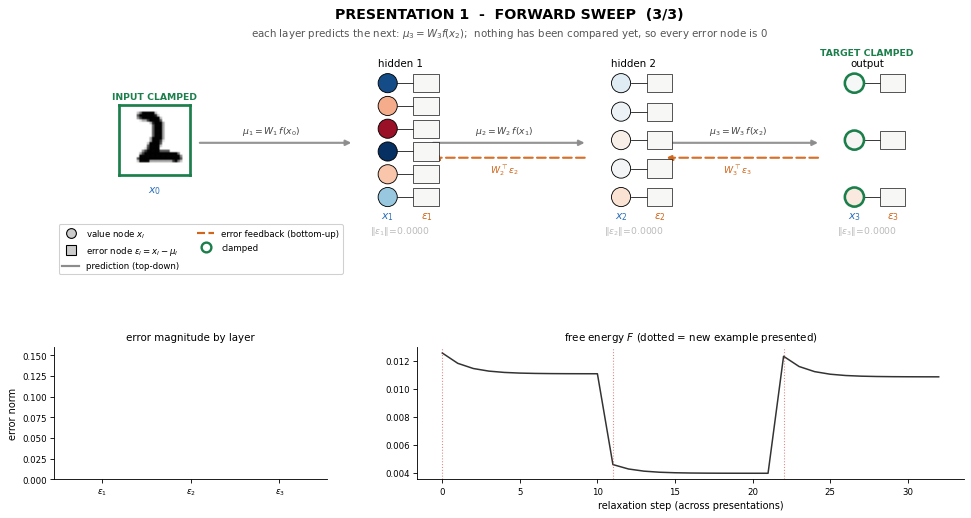

2. Target clamped - error appears at the output ONLY


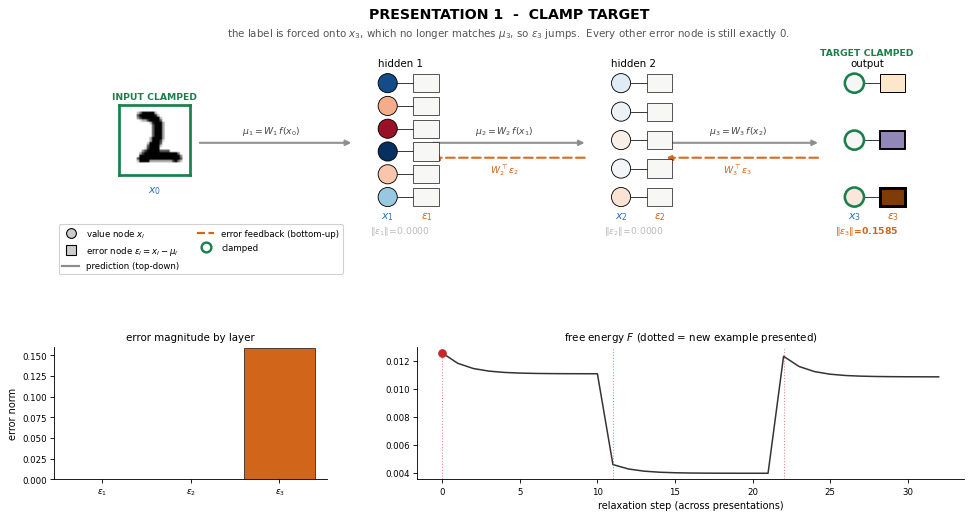

3. Relaxation - the error has spread inward


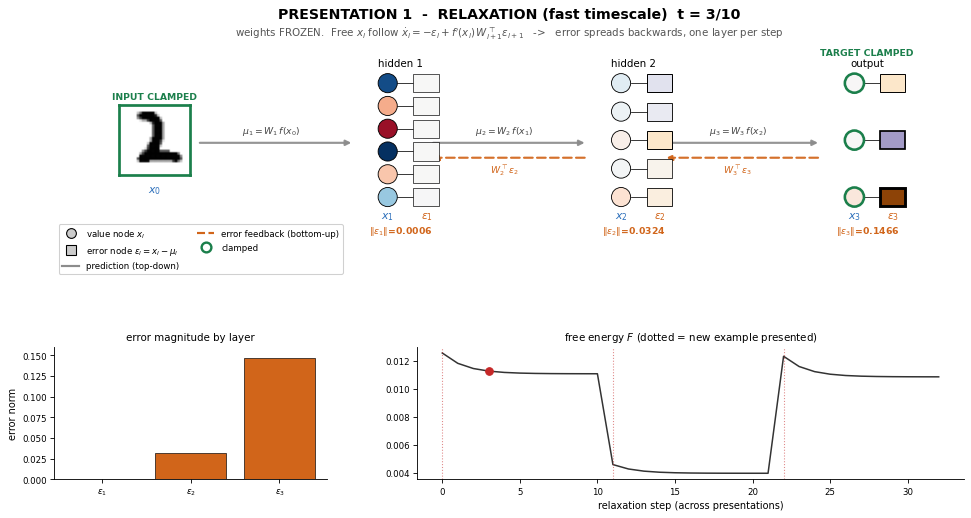

4. Weight update


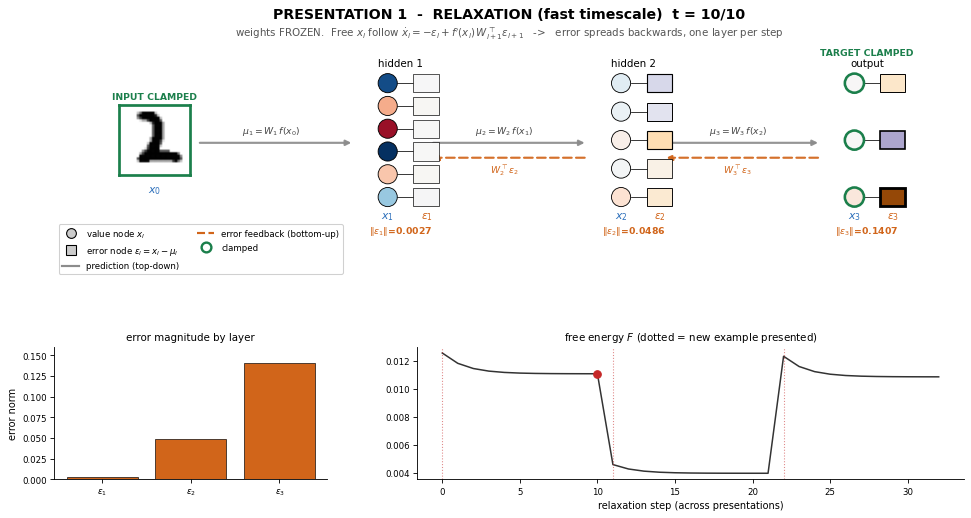

In [18]:
KEY = [(2,  "1. Forward sweep complete"),
       (3,  "2. Target clamped - error appears at the output ONLY"),
       (6,  "3. Relaxation - the error has spread inward"),
       (13, "4. Weight update")]

for idx, caption in KEY:
    fig, ax_net, ax_bar, ax_F, aspect = make_figure(figsize=(12.4, 6.8), dpi=78)
    scene = PCScene(anim_net, aspect=aspect, node_cap=6)
    render(frames[idx], scene, ax_net, ax_bar, ax_F, scales, F_series, boundaries,
           Xa[0].numpy(), anim_net.L)
    print(caption)
    plt.show()

### 10.2 The animation

The full sequence over three presentations. Watch the **error magnitude** panel: on
each new example the output bar jumps first and the inner bars fill in behind it.

saved pc_animation.gif


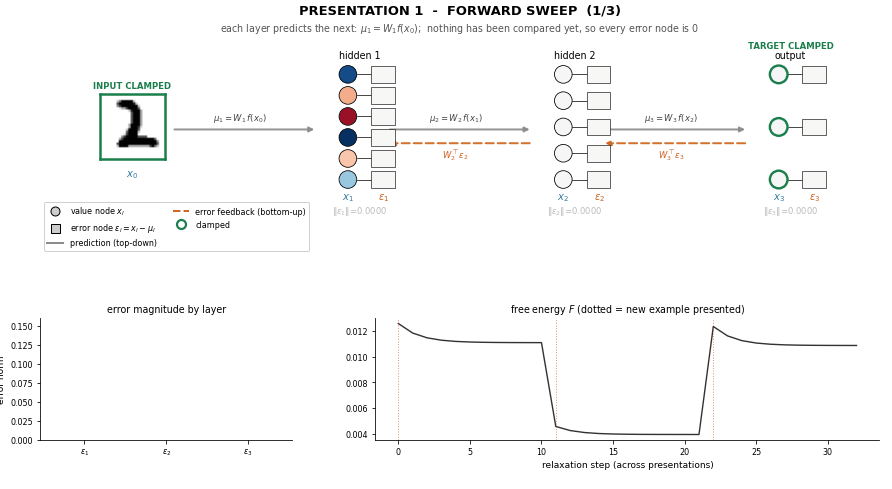

CPU times: user 19.7 s, sys: 306 ms, total: 20 s
Wall time: 20.1 s


In [19]:
%%time
fig, ax_net, ax_bar, ax_F, aspect = make_figure(figsize=(12.4, 6.8), dpi=72)
scene = PCScene(anim_net, aspect=aspect, node_cap=6)

def update(i):
    render(frames[i], scene, ax_net, ax_bar, ax_F, scales, F_series, boundaries,
           Xa[frames[i]["pres"]].numpy(), anim_net.L)
    return []

anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=650, blit=False)
anim.save("pc_animation.gif", writer=animation.PillowWriter(fps=1.6))
plt.close(fig)
print("saved pc_animation.gif")
display(Image(filename="pc_animation.gif"))

## 11. Why the Hebbian rule fails here, and how to improve it

The Hebbian model barely beats chance. It is worth finding out *why* rather than
concluding "biologically plausible learning is bad".

### 11.1 Watching it break

The Hebbian rule has no error term, so nothing ever tells a weight it has gone too far.
The update only ever *accumulates* correlations. Let us track what that does over training.

In [20]:
set_seed(SEED)
diag_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=512)
Xt, yt = next(iter(test_loader))

probe = HebbianLearner(num_outputs=NUM_CLASSES)

def snapshot(tag):
    with torch.no_grad():
        h = probe.net.activation(probe.net.lin1(Xt.reshape(-1, NUM_INPUTS)))
    W1, W2 = probe.net.lin1.weight.data, probe.net.lin2.weight.data
    sat = float((h.gt(.99) | h.lt(.01)).float().mean())
    _, acc = evaluate(probe, test_loader)
    print(f"{tag:>8s}  |W1|={W1.norm():7.2f}  |W2|={W2.norm():7.2f}  "
          f"saturated={sat:6.1%}  row-means={[round(float(r.mean()),3) for r in W2]}  "
          f"acc={acc:5.1f}%")

print(f"{'':>8s}  {'weight growth':^24s}   {'hidden units':^16s}")
snapshot("init")
for ep in range(NUM_EPOCHS):
    for X, y in diag_loader:
        probe.train_batch(X, y)
    if ep in (0, 1, 4, NUM_EPOCHS - 1):
        snapshot(f"epoch {ep+1}")

print("\nWhat is it predicting at the end?")
print("  predicted class counts:", torch.bincount(probe.probs(Xt).argmax(1),
                                                  minlength=NUM_CLASSES).tolist())
print("  true class counts:     ", torch.bincount(yt, minlength=NUM_CLASSES).tolist())

               weight growth           hidden units  
    init  |W1|=   5.76  |W2|=   0.97  saturated=  0.0%  row-means=[-0.015, -0.011, -0.004]  acc= 32.8%
 epoch 1  |W1|=   5.79  |W2|=   0.97  saturated=  0.0%  row-means=[-0.019, -0.003, -0.007]  acc= 36.5%
 epoch 2  |W1|=   5.85  |W2|=   1.02  saturated=  0.2%  row-means=[-0.023, 0.004, -0.011]  acc= 36.1%
 epoch 5  |W1|=   6.69  |W2|=   1.39  saturated= 39.8%  row-means=[-0.034, 0.026, -0.022]  acc= 36.1%
epoch 10  |W1|=  10.33  |W2|=   2.12  saturated= 94.1%  row-means=[-0.049, 0.058, -0.038]  acc= 36.1%

What is it predicting at the end?
  predicted class counts: [0, 512, 0]
  true class counts:      [141, 188, 183]


### 11.2 Two coupled pathologies, one root cause

The weights grow without bound - and that single fact causes two separate failures.

**(a) The hidden layer saturates.** As $\lVert W_1\rVert$ grows, sigmoid units are driven
to 0 or 1. By the last epoch most units are pinned at the extremes, so the hidden
representation degenerates towards a binary code that no longer varies smoothly with the input.

**(b) The output rows acquire a dominant DC offset.** This one is pure arithmetic. The
score for class $c$ is $s_c=\sum_j W_{cj}h_j$. Split each hidden activity into its average
level and its pattern, $h_j = \bar h + \delta_j$:

$$s_c \;=\; \underbrace{\bar h \textstyle\sum_j W_{cj}}_{\text{level term}} \;+\; \underbrace{\textstyle\sum_j W_{cj}\delta_j}_{\text{pattern term}}$$

$\bar h$ is a property of the *image*, identical for every class, so the level term can only
separate classes through each row's **sum** - it carries no information about which digit is
present. Hidden activity has a large positive mean, and the update
$\Delta W_c \propto \sum_{i \in c} h$ accumulates it with nothing to normalise it. Row sums
drift apart, the level term swamps the pattern term, and `argmax` locks onto whichever row
grew largest: **one class, for every input**, which is exactly what the prediction counts show.

**The fix: centre each weight row over its inputs**, i.e. subtract each row's own mean so
that $\sum_j W_{cj}=0$. Then $\bar h$ multiplies zero for every class and only the pattern
term survives. It also bounds the row growth, which relieves (a) as well.

Note this is a *different axis* from the centring already inside `HebbianFunction`. That
line centres over output units (`axis=0`), removing what is common between classes. The fix
centres over inputs (`axis=1`), removing each row's own offset. Same-looking operation,
entirely different effect - and only the second one addresses the failure.

In [21]:
print("--- Hebbian with rows centred over inputs, during training ---")
_, heb_centred = train_extended("hebbian", centre_rows=True, verbose=False)
print("baseline Hebbian accuracy per epoch:", [round(v, 1) for v in results['hebbian']['acc']])
print("row-centred Hebbian accuracy:       ", [round(v, 1) for v in heb_centred['acc']])

# the same correction applied post-hoc, to the already-trained baseline model
with torch.no_grad():
    W2 = probe.net.lin2.weight.data
    h  = probe.net.activation(probe.net.lin1(Xt.reshape(-1, NUM_INPUTS)))
    W2c = W2 - W2.mean(dim=1, keepdim=True)
    acc_before = float(((h @ W2.T ).argmax(1) == yt).float().mean()) * 100
    acc_after  = float(((h @ W2c.T).argmax(1) == yt).float().mean()) * 100
print(f"\npost-hoc centring of the trained weights: {acc_before:.1f}%  ->  {acc_after:.1f}%")
print("\nNote both Hebbian curves are unstable epoch to epoch: with no error term there is")
print("no fixed point being converged to, so accuracy wanders rather than settling.")

--- Hebbian with rows centred over inputs, during training ---
baseline Hebbian accuracy per epoch: [30.4, 36.1, 36.1, 50.1, 54.4, 39.0, 36.1, 36.1, 36.1, 36.1, 36.1]
row-centred Hebbian accuracy:        [30.4, 59.9, 59.2, 38.2, 31.3, 31.2, 31.9, 44.2, 66.8, 66.6, 64.1]

post-hoc centring of the trained weights: 36.7%  ->  76.8%

Note both Hebbian curves are unstable epoch to epoch: with no error term there is
no fixed point being converged to, so accuracy wanders rather than settling.


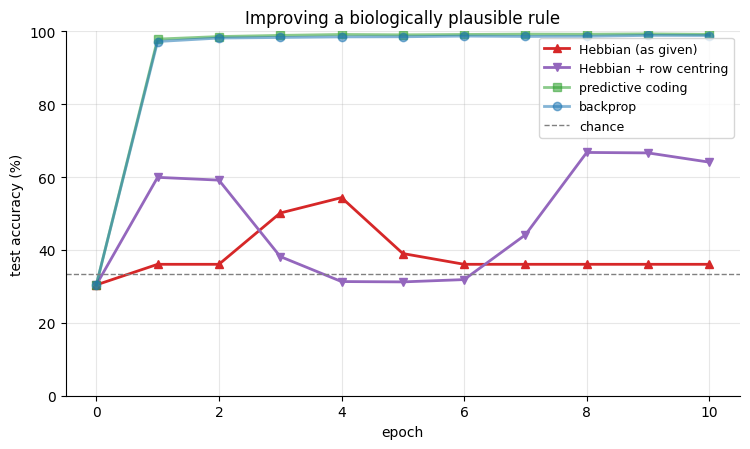

In [22]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.plot(results["hebbian"]["acc"], lw=2, marker="^", color="#D62728", label="Hebbian (as given)")
ax.plot(heb_centred["acc"], lw=2, marker="v", color="#9467BD", label="Hebbian + row centring")
ax.plot(results["predictive_coding"]["acc"], lw=2, marker="s", color="#2CA02C",
        alpha=.55, label="predictive coding")
ax.plot(results["backprop"]["acc"], lw=2, marker="o", color="#1F77B4",
        alpha=.55, label="backprop")
ax.axhline(100 / NUM_CLASSES, ls="--", color="grey", lw=1, label="chance")
ax.set_xlabel("epoch"); ax.set_ylabel("test accuracy (%)")
ax.set_title("Improving a biologically plausible rule"); ax.legend(fontsize=9)
ax.grid(alpha=.3); ax.set_ylim(0, 100)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 12. Conclusions

**Performance.** Predictive coding matches backprop on this task while using only local
updates; the Hebbian rule does not come close. The ordering asked for
(backprop $\geq$ predictive coding $\gg$ Hebbian) holds on the loss curve, though the
accuracy curve shows predictive coding is genuinely level with backprop and its loss gap
is largely output calibration.

**Why predictive coding does so well.** Its error nodes settle to values that are
numerically almost identical to backprop's $\delta$ terms - we measured cosine
similarity $\approx 0.99998$. It gets there not by a backward pass but by letting a
network with a clamped output relax. The error is *created* by the clamp and *transported*
by the dynamics.

**Why the Hebbian rule fails.** It has no error signal at all, so nothing ever corrects a
wrong prediction; it only accumulates correlations. Weights therefore grow without bound,
which breaks the network twice over: the hidden layer saturates, and the output rows come
to be dominated by an uninformative DC offset, collapsing every prediction onto one class.
Centring the rows removes the offset and roughly doubles accuracy (about 36% to 64%). That
is a real improvement, but note the curve remains erratic - with no error term there is no
fixed point to converge to, so accuracy wanders between epochs. The failure was a *specific
and partly fixable* pathology rather than an inherent ceiling, but the absence of an error
signal still costs stability, not just accuracy.

**What makes a local rule work.** Comparing the three, the ingredient that matters is not
locality but whether the rule has access to something error-like:

* Hebbian: pre x post. No error term. Fails.
* Hebbian + clamped output: an error signal at the top layer only, and it never reaches
  the hidden layer. Barely learns.
* Predictive coding: an error node at *every* layer, filled in by relaxation. Matches backprop.

The lesson is that biological plausibility does not require giving up error-driven
learning - it requires finding a way to make the error signal *physically available* at
each synapse. Predictive coding's answer is to spend extra neurons on representing error
explicitly, and extra time on letting those errors settle.

**Caveats worth stating.**

* Only 3 classes and one hidden layer. The Hebbian rule degrades further with more classes.
* Predictive coding's feedback uses $W^{\top}$, the exact transpose of the forward weights.
  Real synapses are not symmetric this way; relaxing this assumption ("feedback alignment")
  is a whole literature.
* Relaxation costs $T$ forward-equivalent passes per example, so predictive coding is
  roughly an order of magnitude more expensive per example than backprop here.